# UTS Soft Computing - Tahap 2 (Evolutionary Tuning)

Notebook ini melakukan optimasi parameter Membership Function (MF) Fuzzy Mamdani menggunakan Genetic Algorithm (GA).

## Install & Import Library

In [17]:
!pip install scikit-fuzzy matplotlib numpy pandas seaborn tqdm scikit-learn

import os
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import skfuzzy as fuzz

from tqdm import tqdm
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
random.seed(42)

print('Library siap digunakan!')

Library siap digunakan!



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Load Data & Preprocessing (Sama seperti Tahap 1)

In [18]:
df = pd.read_csv('../data/credit_risk_dataset.csv')

df_clean = df.copy()
df_clean = df_clean[df_clean['person_age'] <= 80]
df_clean = df_clean[df_clean['person_emp_length'] <= 60]
df_clean['person_emp_length'].fillna(df_clean['person_emp_length'].median(), inplace=True)
df_clean['loan_int_rate'].fillna(df_clean['loan_int_rate'].median(), inplace=True)
df_clean = df_clean.reset_index(drop=True)

features = df_clean[['loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length']].copy()
target = df_clean['loan_status'].copy()

print('Shape awal  :', df.shape)
print('Shape bersih:', df_clean.shape)
print('\nDistribusi target:')
print(target.value_counts())

Shape awal  : (32581, 12)
Shape bersih: (31677, 12)

Distribusi target:
loan_status
0    24852
1     6825
Name: count, dtype: int64


## Universe, Rules, dan Parameter Awal Tahap 1

In [19]:
# Universe of discourse (mengikuti Tahap 1)
x_int_rate = np.arange(5, 24, 0.1)
x_pct_income = np.arange(0, 0.85, 0.01)
x_cred_hist = np.arange(2, 31, 1)
x_risk = np.arange(0, 1.01, 0.01)

# Output MF dipertahankan seperti Tahap 1
mf_risk_safe = fuzz.trimf(x_risk, [0.0, 0.0, 0.4])
mf_risk_caution = fuzz.trimf(x_risk, [0.2, 0.5, 0.8])
mf_risk_risky = fuzz.trimf(x_risk, [0.6, 1.0, 1.0])

rules = [
    {'rate': 'low',    'pct': 'low',    'hist': 'long',   'risk': 'safe'},
    {'rate': 'low',    'pct': 'low',    'hist': 'medium', 'risk': 'safe'},
    {'rate': 'low',    'pct': 'low',    'hist': 'short',  'risk': 'caution'},
    {'rate': 'low',    'pct': 'medium', 'hist': 'long',   'risk': 'safe'},
    {'rate': 'low',    'pct': 'medium', 'hist': 'medium', 'risk': 'caution'},
    {'rate': 'low',    'pct': 'medium', 'hist': 'short',  'risk': 'caution'},
    {'rate': 'low',    'pct': 'high',   'hist': 'long',   'risk': 'caution'},
    {'rate': 'low',    'pct': 'high',   'hist': 'medium', 'risk': 'risky'},
    {'rate': 'low',    'pct': 'high',   'hist': 'short',  'risk': 'risky'},

    {'rate': 'medium', 'pct': 'low',    'hist': 'long',   'risk': 'safe'},
    {'rate': 'medium', 'pct': 'low',    'hist': 'medium', 'risk': 'caution'},
    {'rate': 'medium', 'pct': 'low',    'hist': 'short',  'risk': 'caution'},
    {'rate': 'medium', 'pct': 'medium', 'hist': 'long',   'risk': 'caution'},
    {'rate': 'medium', 'pct': 'medium', 'hist': 'medium', 'risk': 'caution'},
    {'rate': 'medium', 'pct': 'medium', 'hist': 'short',  'risk': 'risky'},
    {'rate': 'medium', 'pct': 'high',   'hist': 'long',   'risk': 'caution'},
    {'rate': 'medium', 'pct': 'high',   'hist': 'medium', 'risk': 'risky'},
    {'rate': 'medium', 'pct': 'high',   'hist': 'short',  'risk': 'risky'},

    {'rate': 'high',   'pct': 'low',    'hist': 'long',   'risk': 'caution'},
    {'rate': 'high',   'pct': 'low',    'hist': 'medium', 'risk': 'caution'},
    {'rate': 'high',   'pct': 'low',    'hist': 'short',  'risk': 'risky'},
    {'rate': 'high',   'pct': 'medium', 'hist': 'long',   'risk': 'caution'},
    {'rate': 'high',   'pct': 'medium', 'hist': 'medium', 'risk': 'risky'},
    {'rate': 'high',   'pct': 'medium', 'hist': 'short',  'risk': 'risky'},
    {'rate': 'high',   'pct': 'high',   'hist': 'long',   'risk': 'risky'},
    {'rate': 'high',   'pct': 'high',   'hist': 'medium', 'risk': 'risky'},
    {'rate': 'high',   'pct': 'high',   'hist': 'short',  'risk': 'risky'},
]

with open('../results/mf_params_tahap1.json', 'r') as f:
    mf_params_tahap1 = json.load(f)

print('Rules:', len(rules))
print('Parameter Tahap 1 berhasil dimuat.')
mf_params_tahap1

Rules: 27
Parameter Tahap 1 berhasil dimuat.


{'loan_int_rate': {'low': [5, 5, 11],
  'medium': [8, 13, 18],
  'high': [15, 23, 23]},
 'loan_percent_income': {'low': [0.0, 0.0, 0.22],
  'medium': [0.15, 0.3, 0.45],
  'high': [0.38, 0.83, 0.83]},
 'cb_person_cred_hist_length': {'short': [2, 2, 7],
  'medium': [4, 10, 16],
  'long': [12, 30, 30]}}

## Fungsi FIS Dinamis (Parameter dari GA)

In [20]:
THRESHOLD = 0.5

VAR_CONFIG = {
    'loan_int_rate': {
        'labels': ['low', 'medium', 'high'],
        'bounds': (5.0, 23.0),
        'x': x_int_rate
    },
    'loan_percent_income': {
        'labels': ['low', 'medium', 'high'],
        'bounds': (0.0, 0.83),
        'x': x_pct_income
    },
    'cb_person_cred_hist_length': {
        'labels': ['short', 'medium', 'long'],
        'bounds': (2.0, 30.0),
        'x': x_cred_hist
    }
}

OUTPUT_MFS = {
    'safe': mf_risk_safe,
    'caution': mf_risk_caution,
    'risky': mf_risk_risky
}

def build_input_mfs(params):
    input_mfs = {}
    for var, cfg in VAR_CONFIG.items():
        x = cfg['x']
        input_mfs[var] = {}
        for label in cfg['labels']:
            a, b, c = params[var][label]
            input_mfs[var][label] = fuzz.trimf(x, [a, b, c])
    return input_mfs

def get_mf_value(var_key, label, value, input_mfs):
    x = VAR_CONFIG[var_key]['x']
    return float(fuzz.interp_membership(x, input_mfs[var_key][label], value))

def mamdani_inference_row(rate_val, pct_val, hist_val, input_mfs):
    aggregated = np.zeros_like(x_risk)

    for rule in rules:
        mu_rate = get_mf_value('loan_int_rate', rule['rate'], rate_val, input_mfs)
        mu_pct = get_mf_value('loan_percent_income', rule['pct'], pct_val, input_mfs)
        mu_hist = get_mf_value('cb_person_cred_hist_length', rule['hist'], hist_val, input_mfs)

        firing = min(mu_rate, mu_pct, mu_hist)
        if firing > 0:
            clipped = np.fmin(firing, OUTPUT_MFS[rule['risk']])
            aggregated = np.fmax(aggregated, clipped)

    if aggregated.max() == 0:
        return 0.5

    return float(fuzz.defuzz(x_risk, aggregated, 'centroid'))

def mamdani_inference_batch(df_input, params, show_progress=False, desc='Inference'):
    input_mfs = build_input_mfs(params)
    scores = []

    iterator = df_input.iterrows()
    if show_progress:
        iterator = tqdm(iterator, total=len(df_input), desc=desc)

    for _, row in iterator:
        score = mamdani_inference_row(
            row['loan_int_rate'],
            row['loan_percent_income'],
            row['cb_person_cred_hist_length'],
            input_mfs
        )
        scores.append(score)

    return np.array(scores)

## Baseline Kinerja Tahap 1 (Sebagai Pembanding)

In [21]:
baseline_scores = mamdani_inference_batch(df_clean, mf_params_tahap1, show_progress=True, desc='Baseline Tahap 1')
baseline_pred = (baseline_scores >= THRESHOLD).astype(int)

baseline_acc = accuracy_score(target, baseline_pred)
baseline_f1 = f1_score(target, baseline_pred, zero_division=0)

print('=' * 55)
print('BASELINE TAHAP 1 (SEBELUM GA)')
print('=' * 55)
print(f'Akurasi : {baseline_acc * 100:.2f}%')
print(f'F1-score: {baseline_f1:.4f}')

Baseline Tahap 1: 100%|██████████| 31677/31677 [00:11<00:00, 2729.70it/s]

BASELINE TAHAP 1 (SEBELUM GA)
Akurasi : 43.73%
F1-score: 0.4003


## Encoding Kromosom dan Constraint

In [22]:
GENE_ORDER = [
    ('loan_int_rate', 'low'), ('loan_int_rate', 'medium'), ('loan_int_rate', 'high'),
    ('loan_percent_income', 'low'), ('loan_percent_income', 'medium'), ('loan_percent_income', 'high'),
    ('cb_person_cred_hist_length', 'short'), ('cb_person_cred_hist_length', 'medium'), ('cb_person_cred_hist_length', 'long')
]

def params_to_chromosome(params):
    genes = []
    for var, label in GENE_ORDER:
        genes.extend(params[var][label])
    return np.array(genes, dtype=float)

def repair_triplet(values, lo, hi):
    vals = np.clip(np.array(values, dtype=float), lo, hi)
    vals.sort()
    return vals.tolist()

def chromosome_to_params(chromosome):
    chromosome = np.array(chromosome, dtype=float).copy()
    repaired = {}

    idx = 0
    for var, label in GENE_ORDER:
        lo, hi = VAR_CONFIG[var]['bounds']
        triplet = repair_triplet(chromosome[idx:idx+3], lo, hi)

        if var not in repaired:
            repaired[var] = {}
        repaired[var][label] = triplet

        idx += 3

    for var, cfg in VAR_CONFIG.items():
        labels = cfg['labels']
        centers = [repaired[var][lab][1] for lab in labels]
        if any(centers[i] > centers[i+1] for i in range(len(centers)-1)):
            sorted_triplets = sorted([repaired[var][lab] for lab in labels], key=lambda t: t[1])
            for lab, tri in zip(labels, sorted_triplets):
                repaired[var][lab] = tri

    return repaired

base_chromosome = params_to_chromosome(mf_params_tahap1)
print('Panjang kromosom:', len(base_chromosome))

Panjang kromosom: 27


## Fungsi Fitness untuk GA

In [23]:
# Agar GA lebih CEPAT, gunakan subset kecil terstratifikasi untuk evaluasi fitness
df_train_ga = df_clean.copy()

if len(df_train_ga) > 5000:
    df_train_ga, _ = train_test_split(
        df_train_ga,
        train_size=5000,
        random_state=42,
        stratify=df_train_ga['loan_status']
    )

df_train_ga = df_train_ga.reset_index(drop=True)
print('Data untuk fitness GA (VERSI RINGAN):', len(df_train_ga))

def evaluate_fitness(chromosome, df_eval, threshold=0.5, alpha=0.4):
    params = chromosome_to_params(chromosome)
    scores = mamdani_inference_batch(df_eval, params, show_progress=False)
    pred = (scores >= threshold).astype(int)

    y_true = df_eval['loan_status'].values
    acc = accuracy_score(y_true, pred)
    f1 = f1_score(y_true, pred, zero_division=0)

    fitness = alpha * acc + (1 - alpha) * f1
    return float(fitness), float(acc), float(f1)

Data untuk fitness GA (VERSI RINGAN): 5000


## Genetic Algorithm

In [24]:
POP_SIZE = 16
N_GENERATIONS = 18
CROSSOVER_RATE = 0.85
MUTATION_RATE = 0.12
ELITISM = 1
TOURNAMENT_K = 3

NOISE_SCALE = np.array([
    0.8, 0.8, 0.8,
    0.8, 0.8, 0.8,
    0.8, 0.8, 0.8,
    0.03, 0.03, 0.03,
    0.03, 0.03, 0.03,
    0.03, 0.03, 0.03,
    1.2, 1.2, 1.2,
    1.2, 1.2, 1.2,
    1.2, 1.2, 1.2
])

def initialize_population(base_chrom, pop_size):
    population = [base_chrom.copy()]
    for _ in range(pop_size - 1):
        noise = np.random.normal(0, NOISE_SCALE)
        indiv = base_chrom + noise
        population.append(params_to_chromosome(chromosome_to_params(indiv)))
    return population

def tournament_selection(population, fitnesses, k=3):
    idxs = np.random.choice(len(population), size=k, replace=False)
    best_idx = idxs[np.argmax([fitnesses[i] for i in idxs])]
    return population[best_idx].copy()

def crossover(parent1, parent2, rate=0.85):
    if np.random.rand() > rate:
        return parent1.copy(), parent2.copy()

    alpha = np.random.rand(len(parent1))
    child1 = alpha * parent1 + (1 - alpha) * parent2
    child2 = alpha * parent2 + (1 - alpha) * parent1

    child1 = params_to_chromosome(chromosome_to_params(child1))
    child2 = params_to_chromosome(chromosome_to_params(child2))
    return child1, child2

def mutate(indiv, rate=0.12):
    mutant = indiv.copy()
    mask = np.random.rand(len(mutant)) < rate
    if mask.any():
        mutant[mask] = mutant[mask] + np.random.normal(0, NOISE_SCALE[mask])
    return params_to_chromosome(chromosome_to_params(mutant))

population = initialize_population(base_chromosome, POP_SIZE)
history_best = []
history_avg = []
best_global = None
best_global_fitness = -1

print(f'Start GA: Pop={POP_SIZE}, Gen={N_GENERATIONS}, Data={len(df_train_ga)}')
print('='*60)

for gen in range(N_GENERATIONS):
    fitness_results = [evaluate_fitness(ind, df_train_ga, threshold=THRESHOLD) for ind in population]
    fitnesses = [r[0] for r in fitness_results]

    ranked_idx = np.argsort(fitnesses)[::-1]
    population = [population[i] for i in ranked_idx]
    fitnesses = [fitnesses[i] for i in ranked_idx]

    gen_best = fitnesses[0]
    gen_avg = float(np.mean(fitnesses))

    history_best.append(gen_best)
    history_avg.append(gen_avg)

    if gen_best > best_global_fitness:
        best_global_fitness = gen_best
        best_global = population[0].copy()

    new_population = population[:ELITISM]

    while len(new_population) < POP_SIZE:
        p1 = tournament_selection(population, fitnesses, k=TOURNAMENT_K)
        p2 = tournament_selection(population, fitnesses, k=TOURNAMENT_K)

        c1, c2 = crossover(p1, p2, rate=CROSSOVER_RATE)
        c1 = mutate(c1, rate=MUTATION_RATE)
        c2 = mutate(c2, rate=MUTATION_RATE)

        new_population.append(c1)
        if len(new_population) < POP_SIZE:
            new_population.append(c2)

    population = new_population

    if (gen + 1) % 3 == 0 or gen == 0:
        print(f'Gen {gen+1:02d}/{N_GENERATIONS} | Best={gen_best:.4f} | Avg={gen_avg:.4f}')

best_params_tahap2 = chromosome_to_params(best_global)
print('='*60)
print('✅ GA selesai. Fitness terbaik:', round(best_global_fitness, 4))

Start GA: Pop=16, Gen=18, Data=5000
Gen 01/18 | Best=0.4807 | Avg=0.4179
Gen 03/18 | Best=0.4814 | Avg=0.4633
Gen 06/18 | Best=0.5426 | Avg=0.5231
Gen 09/18 | Best=0.5546 | Avg=0.5329
Gen 12/18 | Best=0.5580 | Avg=0.5488
Gen 15/18 | Best=0.5643 | Avg=0.5573
Gen 18/18 | Best=0.5763 | Avg=0.5537
✅ GA selesai. Fitness terbaik: 0.5763


## Visualisasi Konvergensi GA

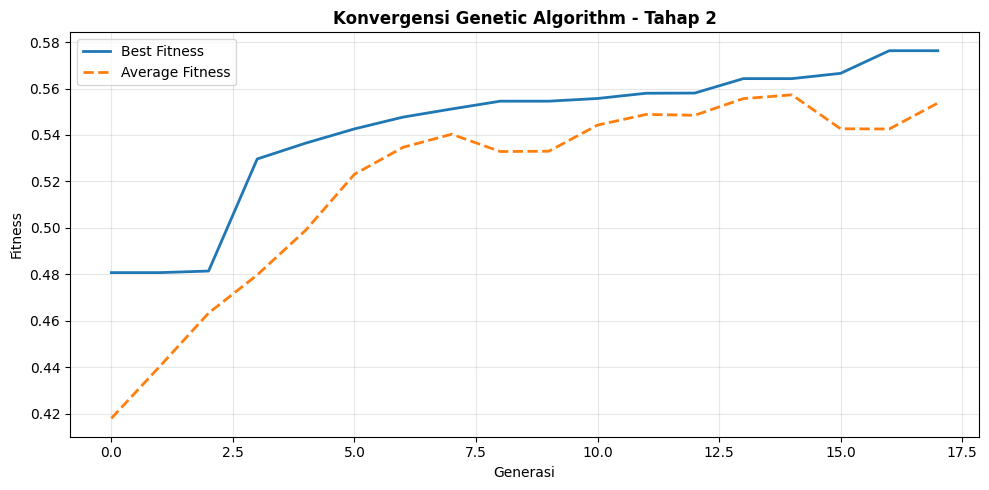

In [25]:
os.makedirs('../results/plots', exist_ok=True)

plt.figure(figsize=(10, 5))
plt.plot(history_best, label='Best Fitness', linewidth=2)
plt.plot(history_avg, label='Average Fitness', linestyle='--', linewidth=2)
plt.title('Konvergensi Genetic Algorithm - Tahap 2', fontweight='bold')
plt.xlabel('Generasi')
plt.ylabel('Fitness')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig('../results/plots/ga_convergence_tahap2.png', dpi=150, bbox_inches='tight')
plt.show()

## Evaluasi Final di Full Dataset (Sebelum vs Sesudah GA)

In [26]:
tuned_scores = mamdani_inference_batch(df_clean, best_params_tahap2, show_progress=True, desc='Evaluasi Tahap 2')
tuned_pred = (tuned_scores >= THRESHOLD).astype(int)

tuned_acc = accuracy_score(target, tuned_pred)
tuned_f1 = f1_score(target, tuned_pred, zero_division=0)

print('=' * 65)
print('PERBANDINGAN KINERJA')
print('=' * 65)
print(f'Baseline Tahap 1 -> Accuracy: {baseline_acc*100:.2f}% | F1: {baseline_f1:.4f}')
print(f'Tuned    Tahap 2 -> Accuracy: {tuned_acc*100:.2f}% | F1: {tuned_f1:.4f}')
print(f'Delta Accuracy     : {(tuned_acc - baseline_acc)*100:.2f}%')
print(f'Delta F1-score     : {(tuned_f1 - baseline_f1):.4f}')

print('\nClassification Report (Tahap 2):\n')
print(classification_report(target, tuned_pred, target_names=['Tidak Default (0)', 'Default (1)']))

Evaluasi Tahap 2: 100%|██████████| 31677/31677 [00:12<00:00, 2584.37it/s]

PERBANDINGAN KINERJA
Baseline Tahap 1 -> Accuracy: 43.73% | F1: 0.4003
Tuned    Tahap 2 -> Accuracy: 67.90% | F1: 0.5050
Delta Accuracy     : 24.17%
Delta F1-score     : 0.1047

Classification Report (Tahap 2):

                   precision    recall  f1-score   support

Tidak Default (0)       0.91      0.66      0.76     24852
      Default (1)       0.38      0.76      0.50      6825

         accuracy                           0.68     31677
        macro avg       0.64      0.71      0.63     31677
     weighted avg       0.79      0.68      0.71     31677



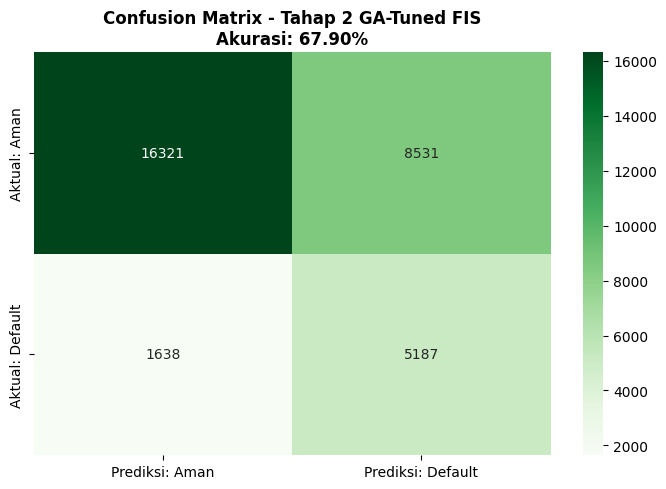

In [27]:
cm = confusion_matrix(target, tuned_pred)

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=['Prediksi: Aman', 'Prediksi: Default'],
    yticklabels=['Aktual: Aman', 'Aktual: Default'],
    ax=ax
)
ax.set_title(f'Confusion Matrix - Tahap 2 GA-Tuned FIS\nAkurasi: {tuned_acc*100:.2f}%', fontweight='bold')
plt.tight_layout()
plt.savefig('../results/confusion_matrix_tahap2.png', dpi=150, bbox_inches='tight')
plt.show()

## Visualisasi MF: Tahap 1 vs Tahap 2

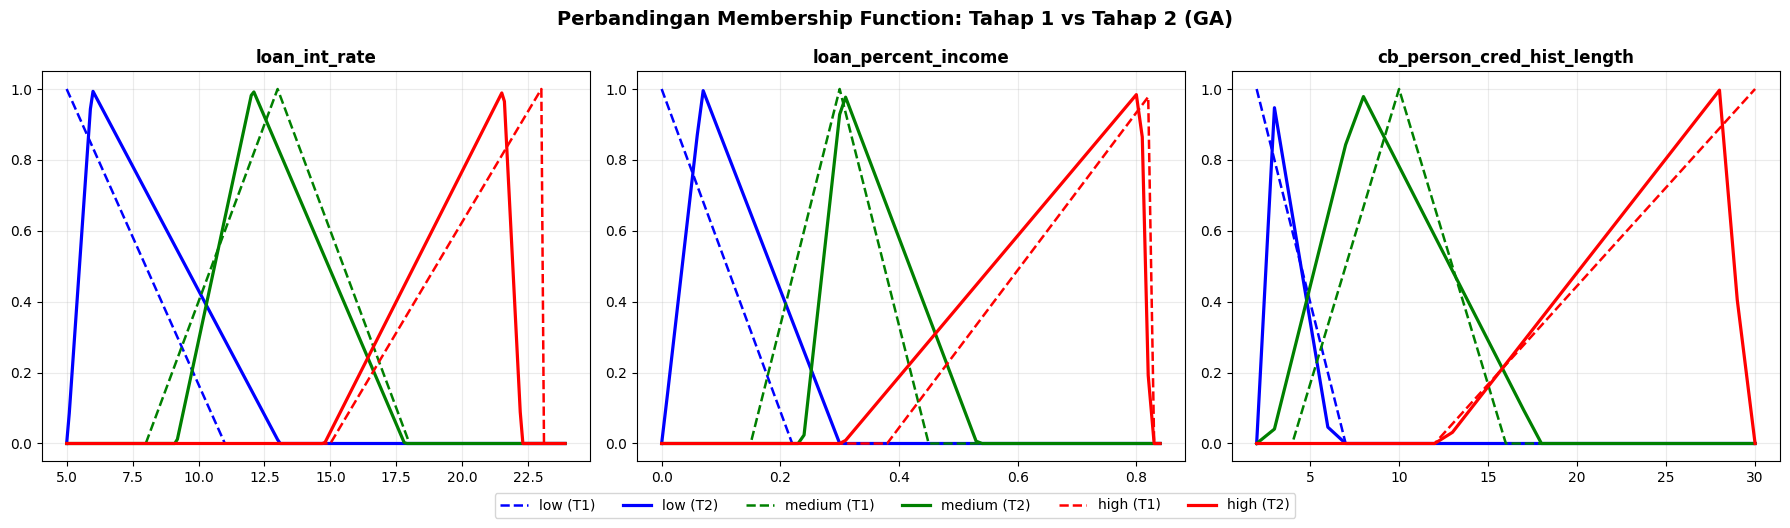

In [28]:
def plot_mf_compare(ax, x, p1, p2, title, labels):
    styles = ['b', 'g', 'r']
    for i, lab in enumerate(labels):
        mf1 = fuzz.trimf(x, p1[lab])
        mf2 = fuzz.trimf(x, p2[lab])

        ax.plot(x, mf1, styles[i] + '--', linewidth=1.8, label=f'{lab} (T1)')
        ax.plot(x, mf2, styles[i] + '-', linewidth=2.3, label=f'{lab} (T2)')

    ax.set_title(title, fontweight='bold')
    ax.set_ylim(-0.05, 1.05)
    ax.grid(True, alpha=0.25)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

plot_mf_compare(
    axes[0], x_int_rate,
    mf_params_tahap1['loan_int_rate'], best_params_tahap2['loan_int_rate'],
    'loan_int_rate', ['low', 'medium', 'high']
)
plot_mf_compare(
    axes[1], x_pct_income,
    mf_params_tahap1['loan_percent_income'], best_params_tahap2['loan_percent_income'],
    'loan_percent_income', ['low', 'medium', 'high']
)
plot_mf_compare(
    axes[2], x_cred_hist,
    mf_params_tahap1['cb_person_cred_hist_length'], best_params_tahap2['cb_person_cred_hist_length'],
    'cb_person_cred_hist_length', ['short', 'medium', 'long']
)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=6, bbox_to_anchor=(0.5, -0.05))
fig.suptitle('Perbandingan Membership Function: Tahap 1 vs Tahap 2 (GA)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/plots/mf_tahap2_vs_tahap1.png', dpi=150, bbox_inches='tight')
plt.show()

## Ablation Study

Bagian ini membandingkan beberapa varian GA/FIS untuk melihat komponen mana yang paling berpengaruh terhadap performa model.

Menjalankan ablation eksperimen parameter ekstrem...
- SmallNoise-Short: run=20/20 | early_stop=False | acc=0.6229 | f1=0.4884
- LargeNoise-Short: run=20/20 | early_stop=False | acc=0.6971 | f1=0.5000
- LargeNoise-Long: run=44/80 | early_stop=True | acc=0.7486 | f1=0.5510
- TinySubset: run=24/60 | early_stop=True | acc=0.6000 | f1=0.4783
- HugeSubset: run=19/60 | early_stop=True | acc=0.5967 | f1=0.4670

Ringkasan Ablation Ekstrem:
         setting  sample_size  pop_size  generations_target  generations_run  mutation_rate  noise_multiplier  stopped_early  accuracy  f1_score  best_fitness
SmallNoise-Short          350         6                  20               20         0.0600            0.5000          False    0.6229    0.4884        0.5422
LargeNoise-Short          350         6                  20               20         0.3500            2.0000          False    0.6971    0.5000        0.5789
 LargeNoise-Long          350         6                  80               44         0.

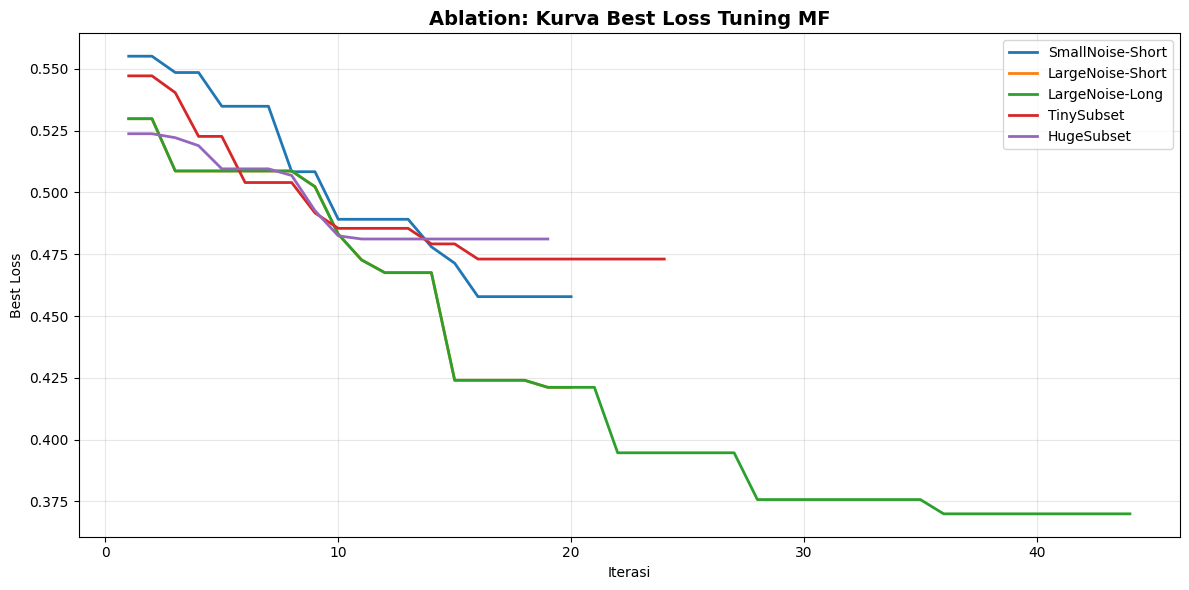


File tersimpan: ../results/ablation_tahap2.json dan ../results/plots/ablation_study_tahap2.png


In [32]:
# Ablation Study - Eksperimen Parameter Ekstrem
# Fokus: melihat pengaruh parameter ekstrem terhadap kualitas solusi dan konvergensi prematur

ABLAT_PATIENCE = 8       # early stop jika tidak ada perbaikan dalam N generasi
ABLAT_MIN_DELTA = 1e-4   # perbaikan minimum agar dianggap improving


def run_extreme_ga_experiment(
    name,
    sample_size,
    pop_size,
    generations,
    mutation_rate,
    noise_multiplier,
    elitism,
    alpha=0.4,
    crossover_rate=0.85,
    seed=42
):
    # Subset data terstratifikasi per eksperimen
    if len(df_clean) > sample_size:
        df_eval, _ = train_test_split(
            df_clean,
            train_size=sample_size,
            random_state=seed,
            stratify=df_clean['loan_status']
        )
    else:
        df_eval = df_clean.copy()

    df_eval = df_eval.reset_index(drop=True)

    # Simpan state RNG agar eksperimen reproducible dan tidak mengganggu state global
    np_state = np.random.get_state()
    py_state = random.getstate()
    np.random.seed(seed)
    random.seed(seed)

    local_noise_scale = NOISE_SCALE * noise_multiplier

    def init_population_local(base_chrom, size):
        pop = [base_chrom.copy()]
        for _ in range(size - 1):
            noise = np.random.normal(0, local_noise_scale)
            indiv = base_chrom + noise
            pop.append(params_to_chromosome(chromosome_to_params(indiv)))
        return pop

    def mutate_local(indiv, rate):
        mutant = indiv.copy()
        mask = np.random.rand(len(mutant)) < rate
        if mask.any():
            mutant[mask] = mutant[mask] + np.random.normal(0, local_noise_scale[mask])
        return params_to_chromosome(chromosome_to_params(mutant))

    def fitness_fn(chromosome):
        params = chromosome_to_params(chromosome)
        scores = mamdani_inference_batch(df_eval, params, show_progress=False)
        pred = (scores >= THRESHOLD).astype(int)
        y_true = df_eval['loan_status'].values
        acc = accuracy_score(y_true, pred)
        f1 = f1_score(y_true, pred, zero_division=0)
        fitness = alpha * acc + (1 - alpha) * f1
        return float(fitness), float(acc), float(f1)

    population = init_population_local(base_chromosome, pop_size)

    best_fitness = -1.0
    best_chrom = None
    history_best_fitness = []

    stagnation_count = 0
    stopped_early = False

    for gen in range(generations):
        fit_results = [fitness_fn(ind) for ind in population]
        fitnesses = [x[0] for x in fit_results]

        rank_idx = np.argsort(fitnesses)[::-1]
        population = [population[i] for i in rank_idx]
        fitnesses = [fitnesses[i] for i in rank_idx]

        gen_best = fitnesses[0]
        history_best_fitness.append(gen_best)

        if gen_best > best_fitness + ABLAT_MIN_DELTA:
            best_fitness = gen_best
            best_chrom = population[0].copy()
            stagnation_count = 0
        else:
            stagnation_count += 1

        # Deteksi konvergensi prematur
        if stagnation_count >= ABLAT_PATIENCE:
            stopped_early = True
            break

        new_population = population[:elitism] if elitism > 0 else []

        while len(new_population) < pop_size:
            p1 = tournament_selection(population, fitnesses, k=min(TOURNAMENT_K, len(population)))
            p2 = tournament_selection(population, fitnesses, k=min(TOURNAMENT_K, len(population)))

            c1, c2 = crossover(p1, p2, rate=crossover_rate)
            c1 = mutate_local(c1, rate=mutation_rate)
            c2 = mutate_local(c2, rate=mutation_rate)

            new_population.append(c1)
            if len(new_population) < pop_size:
                new_population.append(c2)

        population = new_population[:pop_size]

    # Evaluasi akhir parameter terbaik
    best_params = chromosome_to_params(best_chrom)
    final_scores = mamdani_inference_batch(df_eval, best_params, show_progress=False)
    final_pred = (final_scores >= THRESHOLD).astype(int)
    y_true = df_eval['loan_status'].values

    final_acc = float(accuracy_score(y_true, final_pred))
    final_f1 = float(f1_score(y_true, final_pred, zero_division=0))

    # Restore RNG state
    np.random.set_state(np_state)
    random.setstate(py_state)

    return {
        'setting': name,
        'sample_size': int(len(df_eval)),
        'pop_size': pop_size,
        'generations_target': generations,
        'generations_run': len(history_best_fitness),
        'mutation_rate': mutation_rate,
        'noise_multiplier': noise_multiplier,
        'elitism': elitism,
        'stopped_early': stopped_early,
        'best_fitness': float(best_fitness),
        'accuracy': final_acc,
        'f1_score': final_f1,
        'best_loss_history': [1 - x for x in history_best_fitness]
    }


# Konfigurasi ablation ekstrem (mirip gaya tahap 3)
ablation_configs = [
    {
        'name': 'SmallNoise-Short',
        'sample_size': 350,
        'pop_size': 6,
        'generations': 20,
        'mutation_rate': 0.06,
        'noise_multiplier': 0.5,
        'elitism': 1
    },
    {
        'name': 'LargeNoise-Short',
        'sample_size': 350,
        'pop_size': 6,
        'generations': 20,
        'mutation_rate': 0.35,
        'noise_multiplier': 2.0,
        'elitism': 1
    },
    {
        'name': 'LargeNoise-Long',
        'sample_size': 350,
        'pop_size': 6,
        'generations': 80,
        'mutation_rate': 0.35,
        'noise_multiplier': 2.0,
        'elitism': 1
    },
    {
        'name': 'TinySubset',
        'sample_size': 120,
        'pop_size': 6,
        'generations': 60,
        'mutation_rate': 0.12,
        'noise_multiplier': 1.0,
        'elitism': 1
    },
    {
        'name': 'HugeSubset',
        'sample_size': 600,
        'pop_size': 6,
        'generations': 60,
        'mutation_rate': 0.12,
        'noise_multiplier': 1.0,
        'elitism': 1
    }
]

print('Menjalankan ablation eksperimen parameter ekstrem...')
ablation_extreme_results = []

for cfg in ablation_configs:
    result = run_extreme_ga_experiment(
        name=cfg['name'],
        sample_size=cfg['sample_size'],
        pop_size=cfg['pop_size'],
        generations=cfg['generations'],
        mutation_rate=cfg['mutation_rate'],
        noise_multiplier=cfg['noise_multiplier'],
        elitism=cfg['elitism'],
        alpha=0.4,
        crossover_rate=0.85,
        seed=42
    )
    ablation_extreme_results.append(result)
    print(
        f"- {result['setting']}: run={result['generations_run']}/{result['generations_target']} "
        f"| early_stop={result['stopped_early']} | acc={result['accuracy']:.4f} | f1={result['f1_score']:.4f}"
    )

ablation_extreme_df = pd.DataFrame([
    {
        'setting': r['setting'],
        'sample_size': r['sample_size'],
        'pop_size': r['pop_size'],
        'generations_target': r['generations_target'],
        'generations_run': r['generations_run'],
        'mutation_rate': r['mutation_rate'],
        'noise_multiplier': r['noise_multiplier'],
        'stopped_early': r['stopped_early'],
        'accuracy': r['accuracy'],
        'f1_score': r['f1_score'],
        'best_fitness': r['best_fitness']
    }
    for r in ablation_extreme_results
])

print('\nRingkasan Ablation Ekstrem:')
print(ablation_extreme_df.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

# Plot kurva best loss per iterasi
plt.figure(figsize=(12, 6))
for r in ablation_extreme_results:
    x = np.arange(1, len(r['best_loss_history']) + 1)
    plt.plot(x, r['best_loss_history'], linewidth=2, label=r['setting'])

plt.title('Ablation: Kurva Best Loss Tuning MF', fontsize=14, fontweight='bold')
plt.xlabel('Iterasi')
plt.ylabel('Best Loss')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig('../results/plots/tahap2_ablation_loss.png', dpi=150, bbox_inches='tight')
plt.show()

ablation_extreme_summary = {
    'premature_convergence_rule': {
        'patience': ABLAT_PATIENCE,
        'min_delta': ABLAT_MIN_DELTA
    },
    'configs': ablation_configs,
    'results': ablation_extreme_results
}

with open('../results/ablation_tahap2.json', 'w') as f:
    json.dump(ablation_extreme_summary, f, indent=4)

print('\nFile tersimpan: ../results/ablation_tahap2.json dan ../results/plots/ablation_study_tahap2.png')

## Simpan Hasil Tahap 2

In [29]:
# Simpan parameter MF terbaik Tahap 2
with open('../results/mf_params_tahap2.json', 'w') as f:
    json.dump(best_params_tahap2, f, indent=4)

# Simpan hasil prediksi Tahap 2
df_tahap2 = df_clean.copy()
df_tahap2['risk_score_tahap2'] = tuned_scores
df_tahap2['predicted_tahap2'] = tuned_pred
df_tahap2.to_csv('../results/hasil_tahap2_ga_fis.csv', index=False)

# Simpan ringkasan metrik
summary = {
    'baseline_tahap1': {
        'accuracy': float(baseline_acc),
        'f1_score': float(baseline_f1)
    },
    'tuned_tahap2': {
        'accuracy': float(tuned_acc),
        'f1_score': float(tuned_f1),
        'best_fitness_ga': float(best_global_fitness),
        'ga_config': {
            'pop_size': POP_SIZE,
            'generations': N_GENERATIONS,
            'crossover_rate': CROSSOVER_RATE,
            'mutation_rate': MUTATION_RATE,
            'elitism': ELITISM
        }
    }
}

with open('../results/summary_tahap2.json', 'w') as f:
    json.dump(summary, f, indent=4)

print('=' * 60)
print('REKAP AKHIR TAHAP 2 - EVOLUTIONARY TUNING (GA)')
print('=' * 60)
print(f'Accuracy Tahap 1 : {baseline_acc*100:.2f}%')
print(f'Accuracy Tahap 2 : {tuned_acc*100:.2f}%')
print(f'F1-score Tahap 1 : {baseline_f1:.4f}')
print(f'F1-score Tahap 2 : {tuned_f1:.4f}')
print('\nFile tersimpan:')
print('- ../results/mf_params_tahap2.json')
print('- ../results/hasil_tahap2_ga_fis.csv')
print('- ../results/summary_tahap2.json')
print('- ../results/plots/ga_convergence_tahap2.png')
print('- ../results/plots/mf_tahap2_vs_tahap1.png')
print('- ../results/confusion_matrix_tahap2.png')

REKAP AKHIR TAHAP 2 - EVOLUTIONARY TUNING (GA)
Accuracy Tahap 1 : 43.73%
Accuracy Tahap 2 : 67.90%
F1-score Tahap 1 : 0.4003
F1-score Tahap 2 : 0.5050

File tersimpan:
- ../results/mf_params_tahap2.json
- ../results/hasil_tahap2_ga_fis.csv
- ../results/summary_tahap2.json
- ../results/plots/ga_convergence_tahap2.png
- ../results/plots/mf_tahap2_vs_tahap1.png
- ../results/confusion_matrix_tahap2.png
